<a href="https://colab.research.google.com/github/rltxjftlfgdj5/2026_tues_bigdatacomputong_class/blob/main/%EC%A4%91%EA%B0%84%EA%B3%A0%EC%82%AC_%ED%94%84%EB%A1%9C%EA%B7%B8%EB%9E%98%EB%B0%8D_%EA%B3%BC%EC%A0%9C.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# [중간고사 실기 과제] 시계열 기상 데이터 통합 분석 파이프라인 구축
1. 과제 개요

  - 본 과제는 실무 데이터 분석 프로세스를 경험하기 위해 웹상의 기상 데이터를 수집하고, 이를 기계학습 모델링이 가능한 형태의 '깨끗한 데이터'로 가공하는 통합 분석 파이프라인을 개별 함수 단위로 구현하기.

2. 데이터 소스

  - URL: https://github.com/dongupak/DataML/raw/main/csv/weather.csv

  - 주요 컬럼: 지점, 일시, 평균기온, 최대풍속, 평균풍속

3. 핵심 요구 사항 (평가 기준)

  - 모듈화 설계:
    - 모든 기능은 독립적인 함수로 작성되어야 하고,
    - main() 함수에서 제어되어야 함.

  - 데이터 정규화 (Min-Max Scaling):
    - 특정 수치 데이터를 0과 1 사이로 변환하는 함수를 포함해야 함.

  - 시계열 핸들링:
    - 날짜 변환, 인덱스 설정 및 7일 이동 평균 추세선을 생성해야 함.

  - 데이터 재구조화:
    - pivot_table과 groupby를 활용하여 다차원적인 통계량을 산출해야 함.

  - 엑셀 내보내기 (To Excel):
    - 분석 결과인 전처리 데이터, 계절별 통계, 연도별 피벗 테이블을 하나의 엑셀 파일(weather_analysis_report.xlsx)의 별도 시트에 각각 저장해야 함.

  - 다음과 같은 데이터분석 그래프을 생성해야 함.
  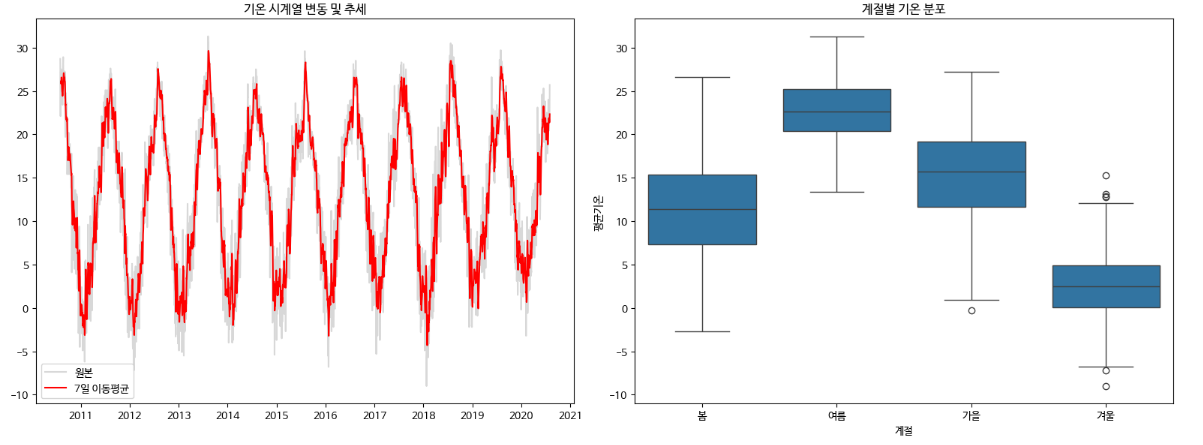

  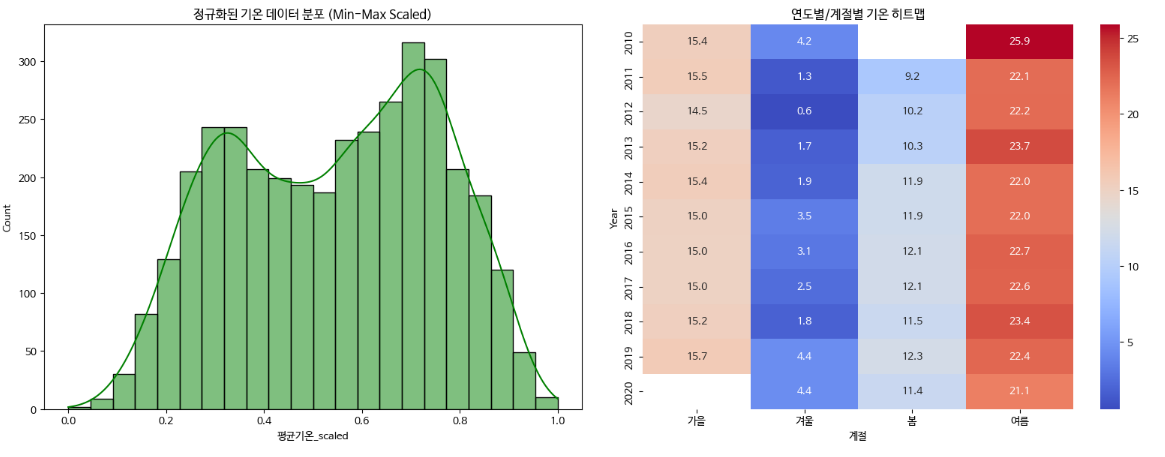



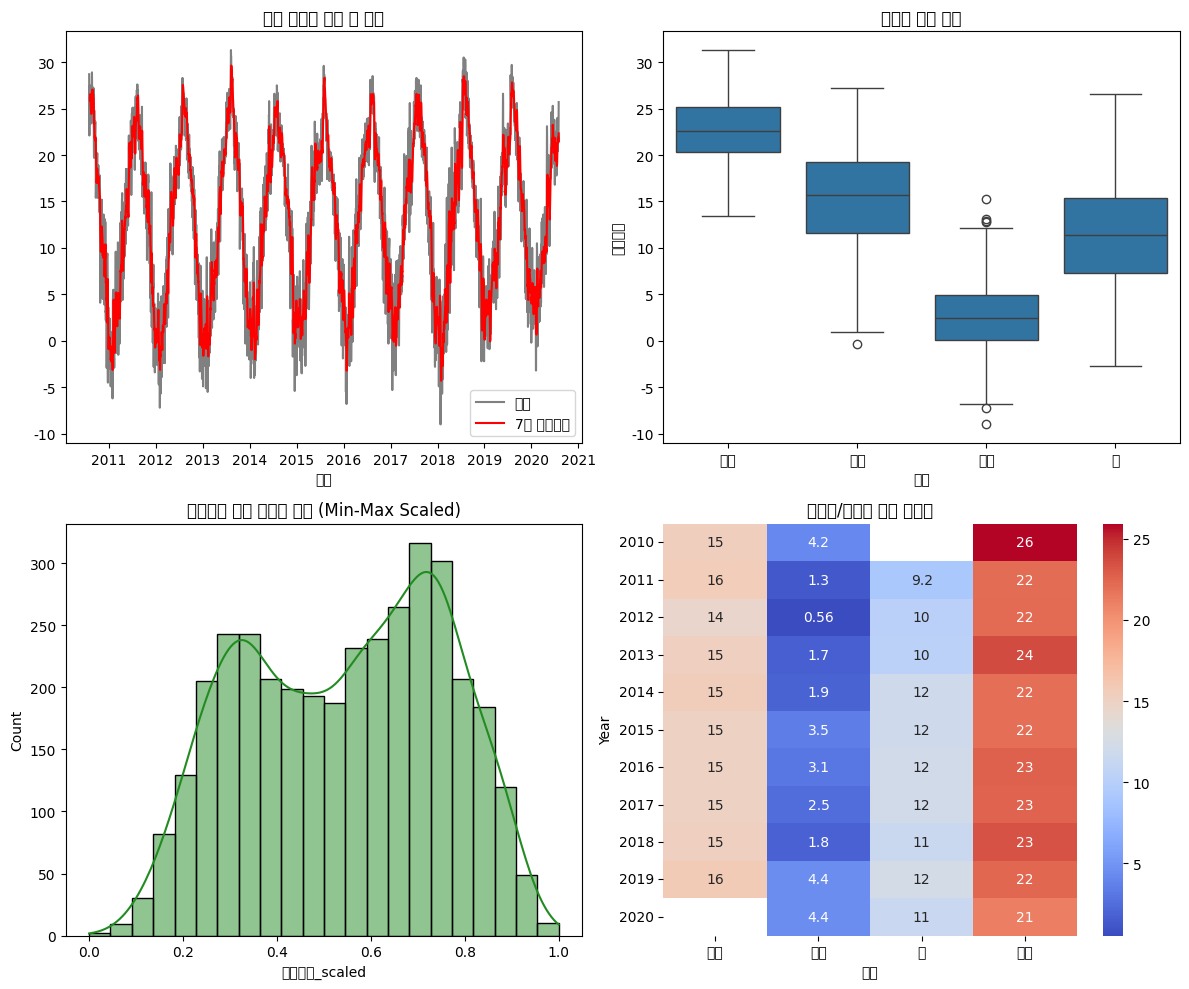

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

def setup_environment():
  warnings.filterwarnings('ignore')
  plt.rcParams['font.family'] = 'DejaVu Sans'
  plt.rcParams['axes.unicode_minus'] = False

def load_data():
  url = "https://github.com/dongupak/DataML/raw/main/csv/weather.csv"
  df = pd.read_csv(url, index_col=0, encoding='CP949')
  return df

def set_datetime(df):
  df.index = pd.to_datetime(df.index)
  df['월'] = df.index.month
  df['요일'] = df.index.dayofweek
  return df

def handle_missing(df):
  df = df.reindex(pd.date_range(df.index.min(), df.index.max()))
  df['평균기온'] = df['평균기온'].interpolate(method='time')
  return df

def detect_outliers(df):
  Q1 = np.percentile(df['평균기온'].dropna(), 25)
  Q3 = np.percentile(df['평균기온'].dropna(), 75)
  df['이상치'] = np.where(
      (df['평균기온'] < Q1) | (df['평균기온'] > Q3),
      1, 0
  )
  return df

def normalize(df):
  df['평균기온_scaled'] = (
      (df['평균기온'] - df['평균기온'].min()) /
      (df['평균기온'].max() - df['평균기온'].min())
  )
  return df

def add_moving_avg(df):
  df['temp_ma'] = df['평균기온'].rolling(7).mean()
  return df

def add_season(df):
  df['계절'] = df['월'].map(lambda m:
      '봄' if m in [3,4,5] else
      '여름' if m in [6,7,8] else
      '가을' if m in [9,10,11] else '겨울'
  )
  return df

def group_analysis(df):
  return df.groupby('계절')['평균기온'].agg(['mean','max','min','std'])

def make_pivot(df):
  return df.pivot_table(
      index=df.index.year,
      columns='계절',
      values='평균기온'
  )

def visualize(df, pivot):

  plt.figure(figsize=(12,10))

  plt.subplot(2,2,1)
  plt.plot(df['평균기온'], color='gray', label='원본')
  plt.plot(df['temp_ma'], color='red', label='7일 이동평균')
  plt.title('기온 시계열 변동 및 추세')
  plt.legend()
  plt.xlabel('날짜')

  plt.subplot(2,2,2)
  sns.boxplot(x='계절', y='평균기온', data=df)
  plt.title('계절별 기온 분포')
  plt.xlabel('계절')

  plt.subplot(2,2,3)
  sns.histplot(
      df['평균기온_scaled'],
      kde=True,
      color='forestgreen',
      line_kws={'color': 'lightgreen'}
  )
  plt.title('정규화된 기온 데이터 분포 (Min-Max Scaled)')
  plt.xlabel('평균기온_scaled')

  plt.subplot(2,2,4)
  sns.heatmap(pivot, annot=True, cmap='coolwarm')
  plt.title('연도별/계절별 기온 히트맵')
  plt.xlabel('계절')
  plt.ylabel('Year')

  plt.tight_layout()
  plt.show()

def save_excel(df, seasonal, pivot):
  with pd.ExcelWriter("weather_analysis_report.xlsx") as writer:
      df.to_excel(writer, sheet_name="전처리데이터")
      seasonal.to_excel(writer, sheet_name="계절통계")
      pivot.to_excel(writer, sheet_name="피벗테이블")

def main():
  setup_environment()

  df = load_data()
  df = set_datetime(df)
  df = handle_missing(df)
  df = detect_outliers(df)
  df = normalize(df)
  df = add_moving_avg(df)
  df = add_season(df)

  seasonal = group_analysis(df)
  pivot = make_pivot(df)

  visualize(df, pivot)
  save_excel(df, seasonal, pivot)

if __name__ == "__main__":
  main()